Dataset loaded successfully.

TASK 2: DATA STRUCTURE & QUALITY ANALYSIS
Dataset Shape: 7043 rows, 21 columns
Duplicate Rows: 0

Missing Values Detected:
TotalCharges    11
dtype: int64
Data Quality Action: Imputed 11 missing TotalCharges entries with 0.0 (new customers).

TASK 3: DESCRIPTIVE STATISTICS

--- Continuous Numerical Features ---
                       mean          std    min      50%      max
tenure            32.371149    24.559481   0.00    29.00    72.00
MonthlyCharges    64.761692    30.090047  18.25    70.35   118.75
TotalCharges    2279.734304  2266.794470   0.00  1394.55  8684.80

--- Categorical Features Summary ---
                 unique               top  freq
customerID         7043        7590-VHVEG     1
gender                2              Male  3555
Partner               2                No  3641
Dependents            2                No  4933
PhoneService          2               Yes  6361
MultipleLines         3                No  3390
InternetService    

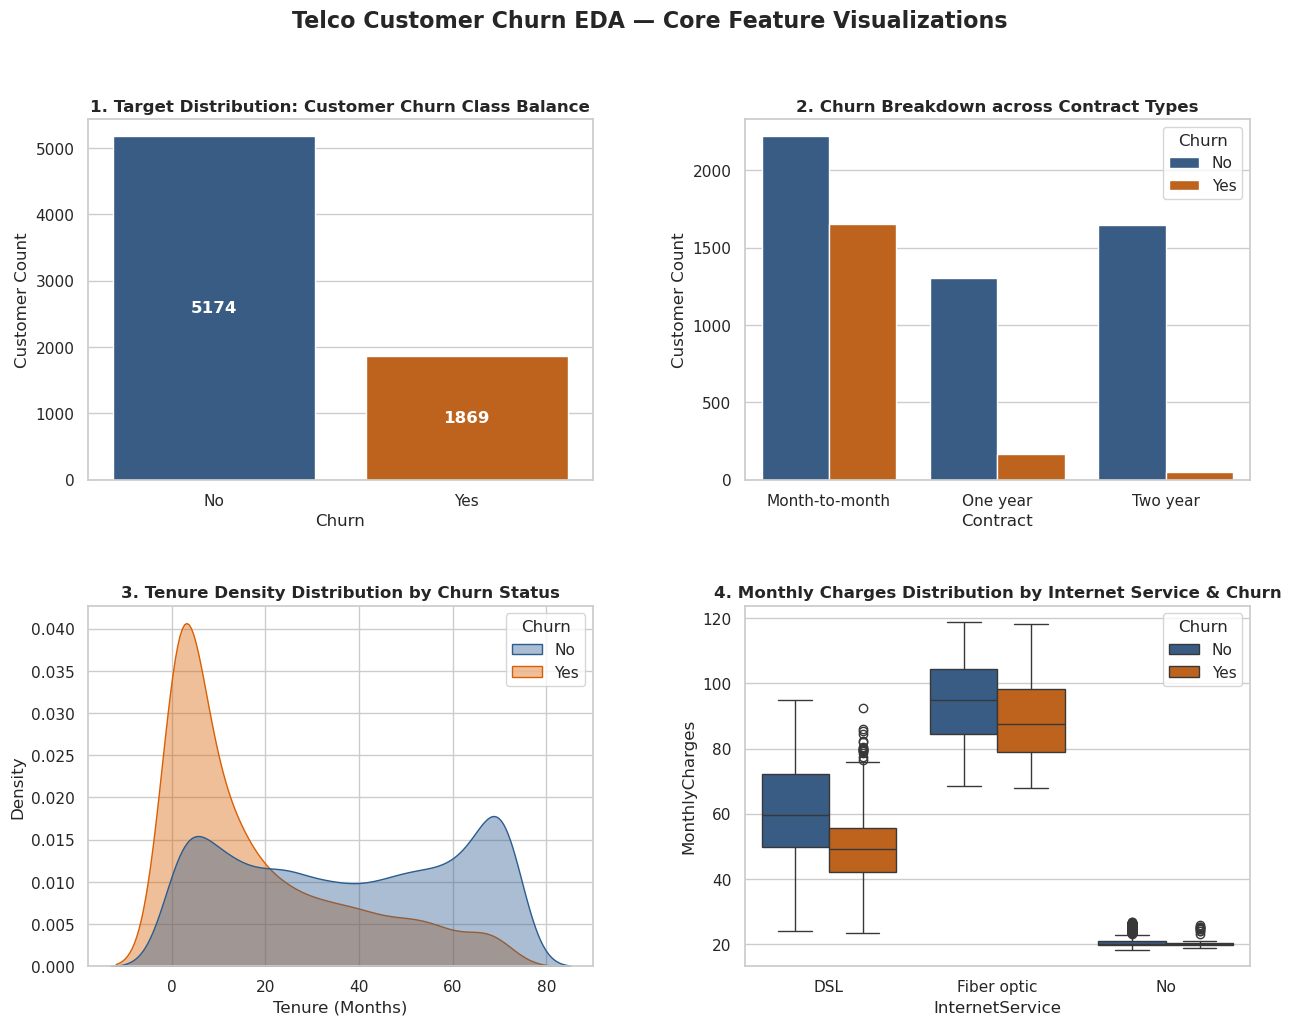

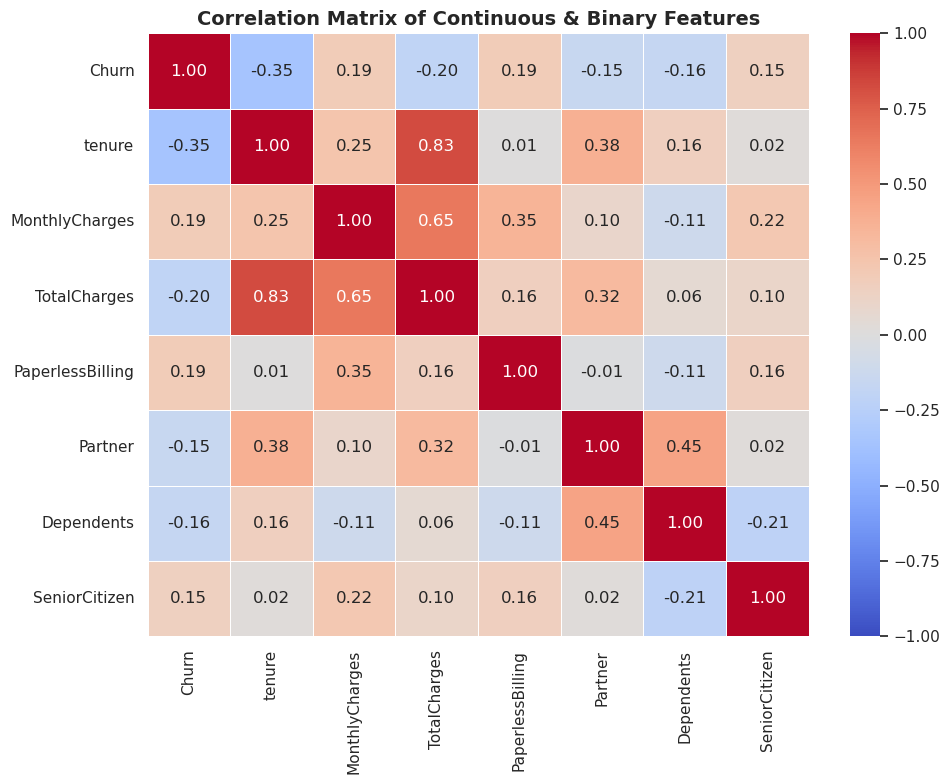

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style configuration for visualizations
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.titlesize'] = 14

# ==============================================================================
# TASK 1: LOAD THE TELCO CUSTOMER CHURN DATASET
# ==============================================================================
file_path = r'C:\Users\bhatt\Downloads\archive (5)\WA_Fn-UseC_-Telco-Customer-Churn.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    # Fallback for standard directory
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Loaded from current working directory.")

# ==============================================================================
# TASK 2: ANALYZE STRUCTURE, DATA TYPES, MISSING VALUES, & DUPLICATES
# ==============================================================================
print("\n" + "="*50)
print("TASK 2: DATA STRUCTURE & QUALITY ANALYSIS")
print("="*50)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Duplicate Rows: {df.duplicated().sum()}")

# Correcting TotalCharges data type issue (contains whitespace strings ' ')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Inspect missing values after coercion
missing_series = df.isnull().sum()
missing_cols = missing_series[missing_series > 0]
print("\nMissing Values Detected:")
print(missing_cols)

# Impute TotalCharges missing values (occurs when tenure == 0)
df['TotalCharges'].fillna(0.0, inplace=True)
print("Data Quality Action: Imputed 11 missing TotalCharges entries with 0.0 (new customers).")

# ==============================================================================
# TASK 3: DESCRIPTIVE STATISTICAL ANALYSIS
# ==============================================================================
print("\n" + "="*50)
print("TASK 3: DESCRIPTIVE STATISTICS")
print("="*50)
print("\n--- Continuous Numerical Features ---")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T[['mean', 'std', 'min', '50%', 'max']])

print("\n--- Categorical Features Summary ---")
print(df.describe(include=['O']).T[['unique', 'top', 'freq']])

print("\n--- Target Class Balance ('Churn') ---")
print(df['Churn'].value_counts(normalize=True).round(4) * 100)

# ==============================================================================
# TASK 4: CREATE AT LEAST FOUR RELEVANT VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# Visual 1: Target Class Balance
sns.countplot(data=df, x='Churn', palette=['#2b5c8f', '#d95f02'], ax=axes[0, 0])
axes[0, 0].set_title('1. Target Distribution: Customer Churn Class Balance', fontweight='bold')
axes[0, 0].set_ylabel('Customer Count')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold')

# Visual 2: Churn Rate by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2b5c8f', '#d95f02'], ax=axes[0, 1])
axes[0, 1].set_title('2. Churn Breakdown across Contract Types', fontweight='bold')
axes[0, 1].set_ylabel('Customer Count')

# Visual 3: Tenure KDE Distribution by Churn
sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, fill=True, 
            palette=['#2b5c8f', '#d95f02'], ax=axes[1, 0], alpha=0.4)
axes[1, 0].set_title('3. Tenure Density Distribution by Churn Status', fontweight='bold')
axes[1, 0].set_xlabel('Tenure (Months)')

# Visual 4: Monthly Charges Boxplot across Internet Service
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges', hue='Churn', 
            palette=['#2b5c8f', '#d95f02'], ax=axes[1, 1])
axes[1, 1].set_title('4. Monthly Charges Distribution by Internet Service & Churn', fontweight='bold')

plt.suptitle('Telco Customer Churn EDA — Core Feature Visualizations', fontsize=16, fontweight='bold', y=0.98)
plt.show()

# ==============================================================================
# TASK 5: CORRELATION MATRIX AND HEATMAP
# ==============================================================================
# Convert binary target and features to numeric 0/1 for correlation analysis
df_corr = df.copy()
binary_map = {'Yes': 1, 'No': 0}
df_corr['Churn'] = df_corr['Churn'].map(binary_map)
df_corr['PaperlessBilling'] = df_corr['PaperlessBilling'].map(binary_map)
df_corr['Partner'] = df_corr['Partner'].map(binary_map)
df_corr['Dependents'] = df_corr['Dependents'].map(binary_map)
df_corr['SeniorCitizen'] = df_corr['SeniorCitizen']

corr_cols = ['Churn', 'tenure', 'MonthlyCharges', 'TotalCharges', 
             'PaperlessBilling', 'Partner', 'Dependents', 'SeniorCitizen']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Continuous & Binary Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()